# Linear Regression & Cost Functions

Linear regression fundamentals, cost functions, and production analysis for subsurface applications.

This notebook covers:
- Building and evaluating linear regression models for permeability prediction
- Understanding cost functions and optimization
- Analyzing production decline and water cut trends using polynomial regression

**Key Concepts:**
- Linear regression: Predicting one continuous variable from another
- Cost functions: Measuring model prediction error
- Gradient descent: Optimization algorithm to minimize cost
- Production analysis: Understanding well performance over time

---

## Part 1: Linear Regression Fundamentals

Linear regression models the relationship between independent variable(s) and a dependent variable.
For subsurface applications, we model productivity index (PI) as a function of permeability × thickness (KH).

**Formula:** PI = slope × KH + intercept + noise

**R² Score:** Measures goodness of fit (0 to 1, higher is better)

C:\Users\NadirZeynalli\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\_param_validation.py:11: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.sparse import csr_matrix, issparse


WELL DATA SUMMARY
KH (mD·m): [ 50  80 100 150 200 250]
Productivity Index (STB/day/psi): [1.19934283 1.67234714 2.22953771 3.40460597 4.05316933 5.05317261]


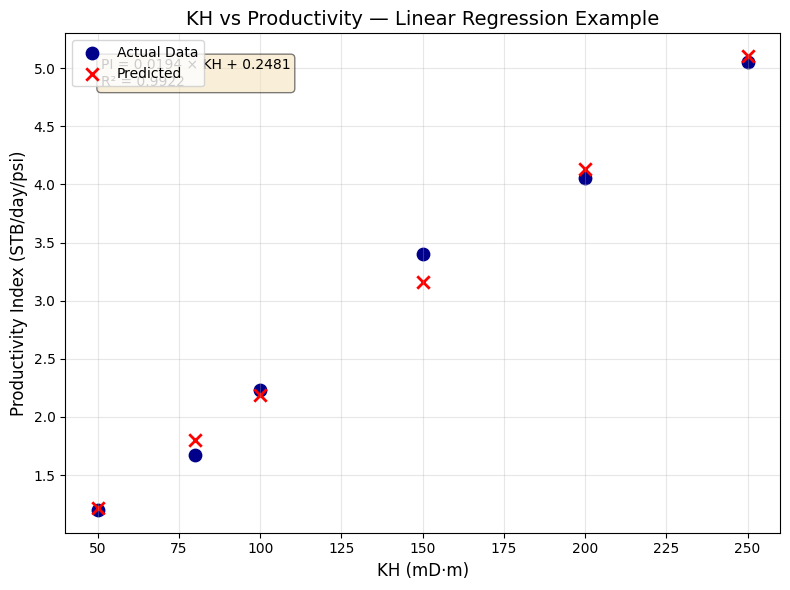


Model Coefficients:
  Slope: 0.019426
  Intercept: 0.248086
  R² Score: 0.9922


In [1]:
"""
Linear Regression Model: KH vs Productivity Index
===================================================
Demonstrates fitting a linear regression model to subsurface data.
Models relationship: PI = slope × KH + intercept
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)

# Generate synthetic well data
# KH: Permeability × Thickness (mD·m) - measure of productive capacity
KH = np.array([50, 80, 100, 150, 200, 250]).reshape(-1, 1)

# Define true linear relationship
true_slope = 0.02          # Productivity increases with KH
true_intercept = 0.1       # Base productivity

# Add realistic noise to simulate field measurements
noise = np.random.normal(0, 0.2, KH.shape)
Productivity = true_slope * KH + true_intercept + noise

print("=" * 60)
print("WELL DATA SUMMARY")
print("=" * 60)
print("KH (mD·m):", KH.flatten())
print("Productivity Index (STB/day/psi):", Productivity.flatten())

# Fit linear regression model
model = LinearRegression()
model.fit(KH, Productivity)

# Make predictions
predicted_PI = model.predict(KH)

# Calculate model performance
r2 = r2_score(Productivity, predicted_PI)

# Visualize regression line and data points
plt.figure(figsize=(8, 6))
plt.scatter(KH, Productivity, s=80, label='Actual Data', color='darkblue')
plt.scatter(KH, predicted_PI, s=80, marker='x', label='Predicted', color='red', linewidth=2)
plt.xlabel("KH (mD·m)", fontsize=12)
plt.ylabel("Productivity Index (STB/day/psi)", fontsize=12)
plt.title("KH vs Productivity — Linear Regression Example", fontsize=14)

# Add equation and R² to plot
equation_text = f"PI = {model.coef_[0][0]:.4f} × KH + {model.intercept_[0]:.4f}\nR² = {r2:.4f}"
plt.text(0.05, 0.95, equation_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nModel Coefficients:")
print(f"  Slope: {model.coef_[0][0]:.6f}")
print(f"  Intercept: {model.intercept_[0]:.6f}")
print(f"  R² Score: {r2:.4f}")
print("=" * 60)

In [2]:
"""
Create summary table of well data
"""
import pandas as pd

data_table = pd.DataFrame({
    'Well #': range(1, len(KH) + 1),
    'KH (mD·m)': KH.flatten(),
    'Productivity Index (STB/day/psi)': Productivity.flatten()
})

print("\nWELL DATA TABLE:")
print(data_table.to_string(index=False))
print("\nStatistics:")
print(f"  KH Average: {data_table['KH (mD·m)'].mean():.2f}")
print(f"  KH Std Dev: {data_table['KH (mD·m)'].std():.2f}")
print(f"  PI Average: {data_table['Productivity Index (STB/day/psi)'].mean():.4f}")


WELL DATA TABLE:
 Well #  KH (mD·m)  Productivity Index (STB/day/psi)
      1         50                          1.199343
      2         80                          1.672347
      3        100                          2.229538
      4        150                          3.404606
      5        200                          4.053169
      6        250                          5.053173

Statistics:
  KH Average: 138.33
  KH Std Dev: 76.27
  PI Average: 2.9354


### Data Summary

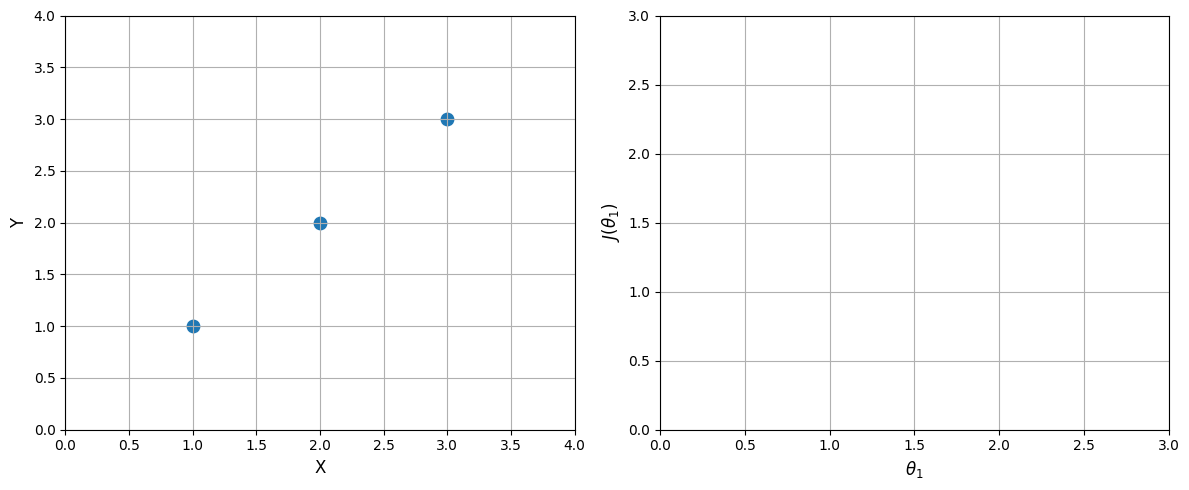

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter([1, 2, 3], [1, 2, 3], s=80)
axes[0].set_xlabel("X", fontsize=12)
axes[0].set_ylabel("Y", fontsize=12)
axes[0].set_xlim(0, 4)
axes[0].set_ylim(0, 4)
axes[0].grid(True)

axes[1].set_xlabel(r'$\theta_1$', fontsize=12)
axes[1].set_ylabel(r'$J(\theta_1)$', fontsize=12)
axes[1].set_xlim(0, 3)
axes[1].set_ylim(0, 3)
axes[1].grid(True)
plt.tight_layout()
plt.show()

---

## Part 2: Cost Function Visualization

### Understanding Cost Functions

A **cost function** measures how poorly our model is performing. It quantifies the difference between predicted and actual values.

**Common Cost Functions:**
- **Mean Squared Error (MSE):** J(θ) = (1/m) × Σ(prediction - actual)²
- **Visualized as:** A mathematical surface showing error for different parameter values

**Key Insight:** We want to find parameters that minimize the cost function - this is the goal of optimization algorithms like gradient descent.

### Basic 2D Cost Function Demonstration

Below we visualize both the data and the corresponding cost function surface for two parameters (θ₁, θ₂).

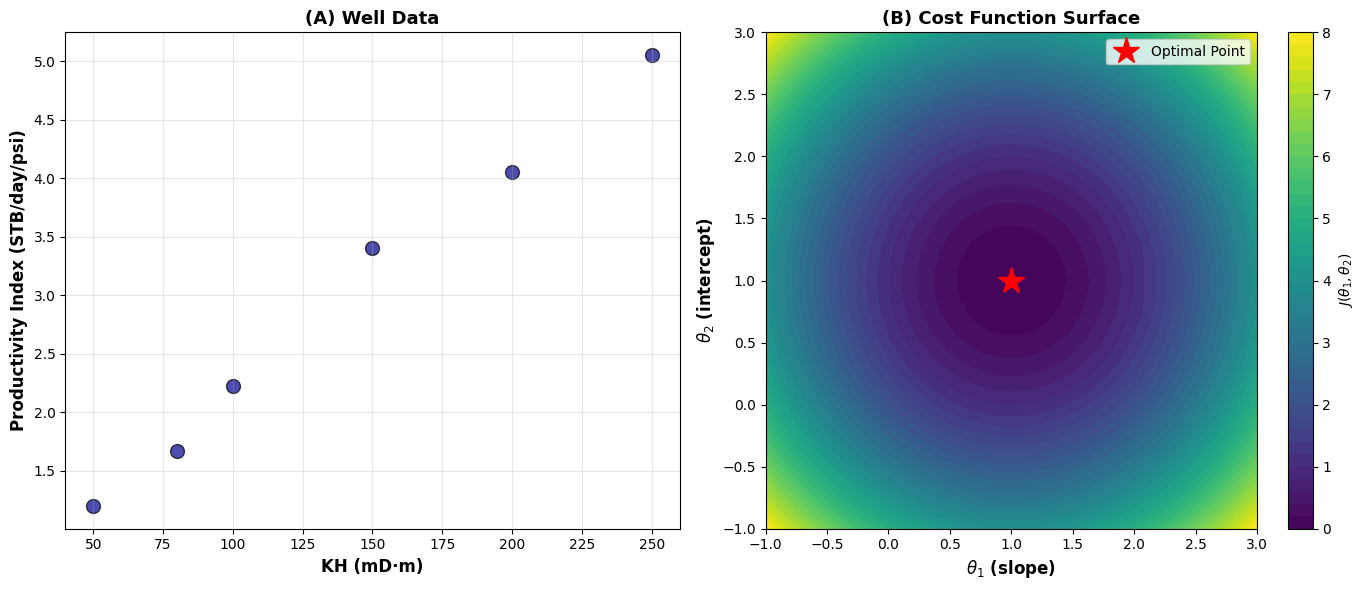

COST FUNCTION INTERPRETATION:
• Contours represent lines of equal cost
• Red star marks the optimal parameter values (minimum cost)
• Gradient descent algorithm moves downhill toward the minimum


In [4]:
"""
Visualization of 2D Cost Function
===================================
Left plot: Original data (KH vs Productivity)
Right plot: Cost function surface (J vs theta parameters)

The contour plot shows:
- Darker regions: Lower cost (better fit)
- Lighter regions: Higher cost (worse fit)
- Valley: Optimal parameter values
"""

fig = plt.figure(figsize=(14, 6))

# Left plot: Data
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(KH, Productivity, s=100, color='darkblue', alpha=0.7, edgecolors='black')
ax1.set_xlabel("KH (mD·m)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Productivity Index (STB/day/psi)", fontsize=12, fontweight='bold')
ax1.set_title("(A) Well Data", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Right plot: Cost function contour
ax2 = fig.add_subplot(1, 2, 2)
theta_1 = np.linspace(-1, 3, 100)
theta_2 = np.linspace(-1, 3, 100)
Theta_1, Theta_2 = np.meshgrid(theta_1, theta_2)

# Simple quadratic cost function: J = (θ₁ - 1)² + (θ₂ - 1)²
J = (Theta_1 - 1)**2 + (Theta_2 - 1)**2

contour = ax2.contourf(Theta_1, Theta_2, J, levels=50, cmap='viridis')
ax2.plot(1, 1, 'r*', markersize=20, label='Optimal Point')  # Mark the minimum
ax2.set_xlabel(r'$\theta_1$ (slope)', fontsize=12, fontweight='bold')
ax2.set_ylabel(r'$\theta_2$ (intercept)', fontsize=12, fontweight='bold')
ax2.set_title("(B) Cost Function Surface", fontsize=13, fontweight='bold')
ax2.set_xlim(-1, 3)
ax2.set_ylim(-1, 3)
ax2.legend()

cbar = fig.colorbar(contour, ax=ax2, label=r'$J(\theta_1, \theta_2)$')
plt.tight_layout()
plt.show()

print("COST FUNCTION INTERPRETATION:")
print("=" * 60)
print("• Contours represent lines of equal cost")
print("• Red star marks the optimal parameter values (minimum cost)")
print("• Gradient descent algorithm moves downhill toward the minimum")
print("=" * 60)

### 3D Cost Function Contour Plot

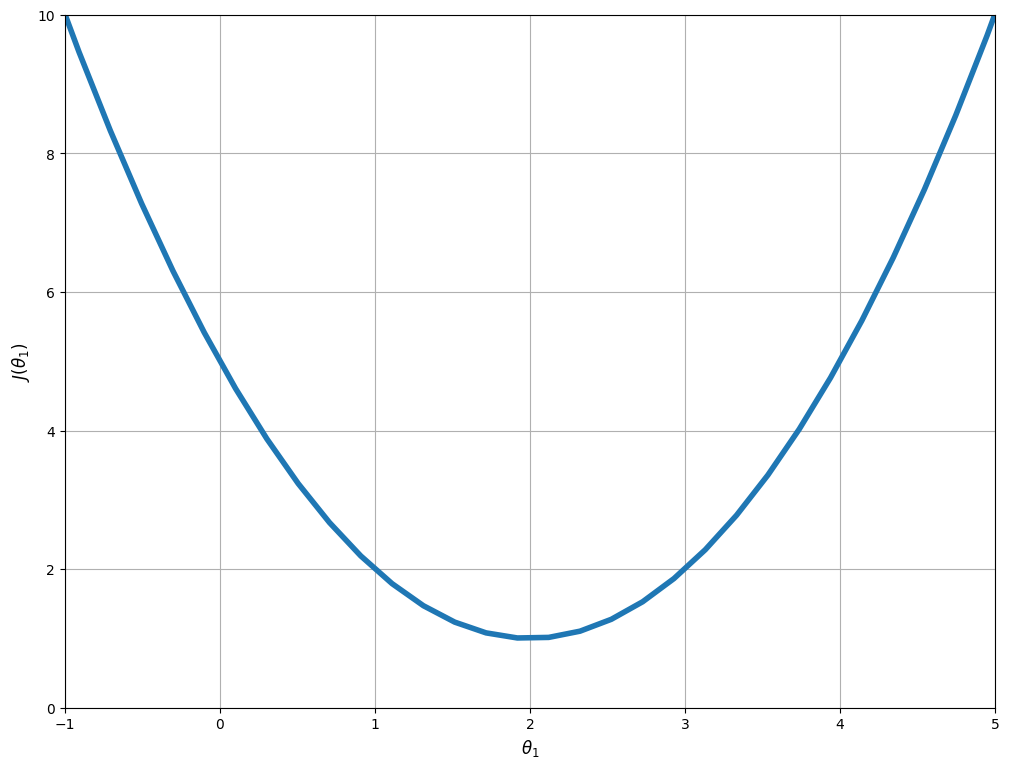

In [5]:
theta_1 = np.linspace(-10, 10, 100)
J = (theta_1 - 2)**2 + 1
plt.figure(figsize=(12, 9))
plt.plot(theta_1, J, linewidth=4)
plt.xlabel(r'$\theta_1$', fontsize=12)
plt.ylabel(r'$J(\theta_1)$', fontsize=12)
plt.xlim(-1, 5)
plt.ylim(0, 10)
plt.grid(True)
plt.show()

### 1D Cost Function (Parabola)

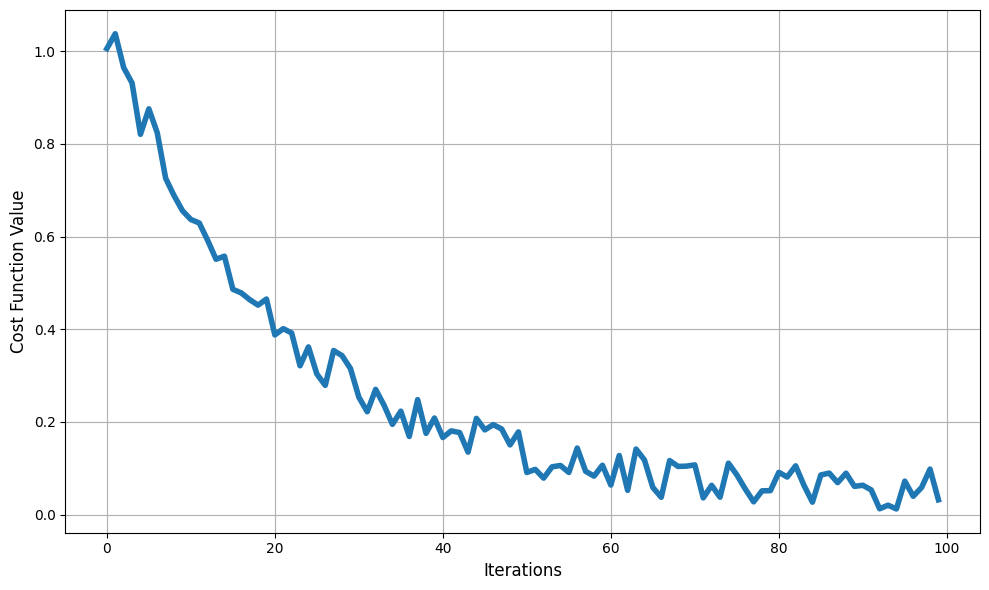

In [6]:
iterations = np.arange(0, 100)
cost_values = np.exp(-0.05 * iterations) + 0.1 * np.random.rand(100)
plt.figure(figsize=(10, 6))
plt.plot(iterations, cost_values, linewidth=4)
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Cost Function Value", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Gradient Descent Convergence

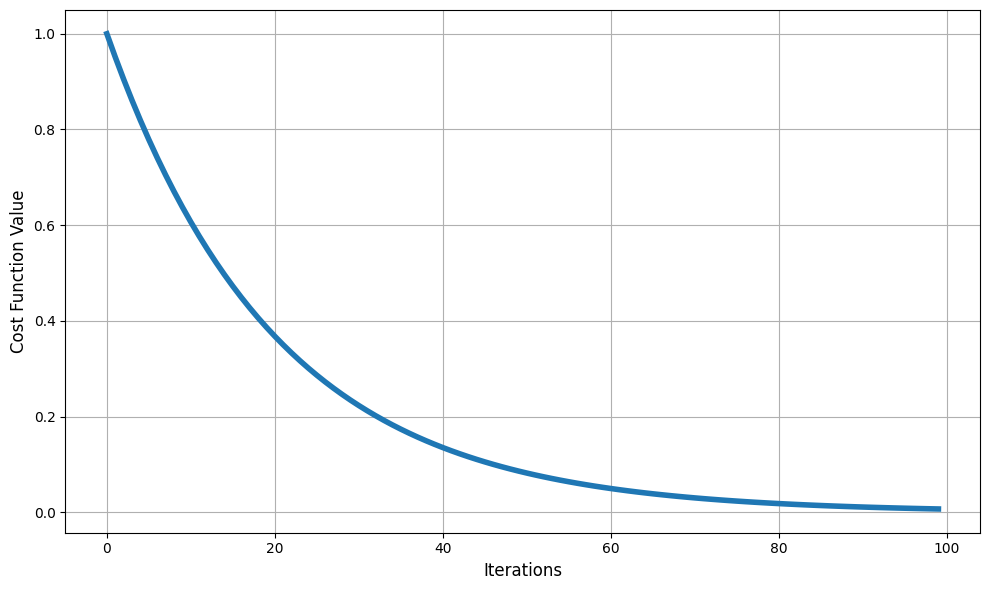

In [7]:
iterations = np.arange(0, 100)
cost_values = np.exp(-0.05 * iterations)
plt.figure(figsize=(10, 6))
plt.plot(iterations, cost_values, linewidth=4)
plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Cost Function Value", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

### Ideal Convergence (Smooth)

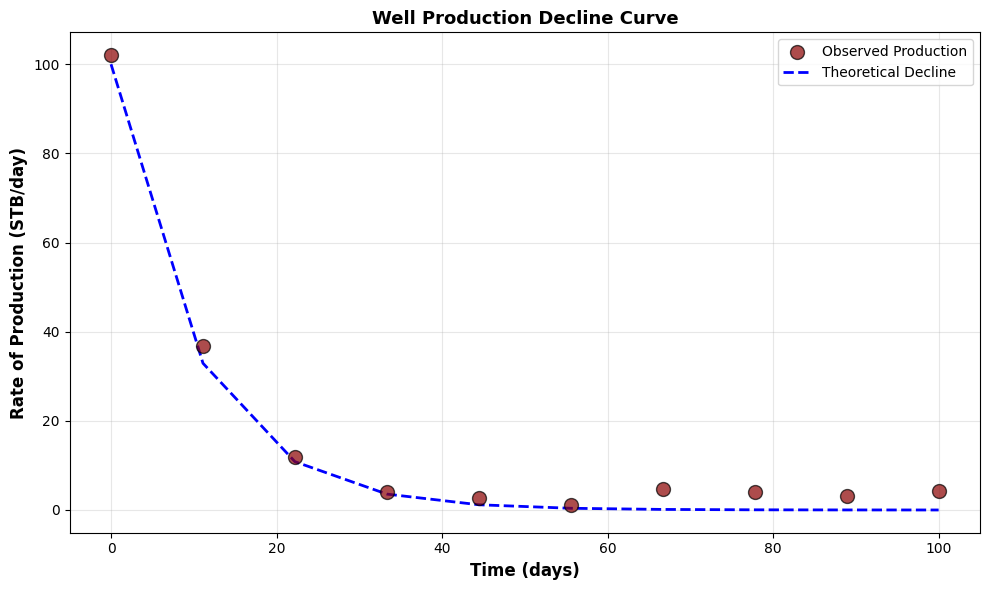

DECLINE CURVE SUMMARY:
Initial Production Rate (q₀): 100.00 STB/day
Decline Rate Constant (D): 0.1000 day⁻¹
Production after 100 days: 4.36 STB/day
Total Decline: 95.6%


In [8]:
"""
Exponential Decline Curve Analysis
===================================
Models production decline: q(t) = q₀ × e^(-D×t)
where: q₀ = initial rate, D = decline rate constant
"""

# Generate decline curve data
# Exponential decline mimics real production behavior
time = np.linspace(0, 100, 10)
q_initial = 100  # Initial production rate (STB/day)
decline_rate = 0.1  # Decline constant
rate_of_production = q_initial * np.exp(-decline_rate * time) + 5 * np.random.rand(10)

# Plot decline curve
plt.figure(figsize=(10, 6))
plt.scatter(time, rate_of_production, s=100, color='darkred', alpha=0.7, 
            edgecolors='black', label='Observed Production', zorder=3)
plt.plot(time, q_initial * np.exp(-decline_rate * time), 'b--', linewidth=2, label='Theoretical Decline')

plt.xlabel("Time (days)", fontsize=12, fontweight='bold')
plt.ylabel("Rate of Production (STB/day)", fontsize=12, fontweight='bold')
plt.title("Well Production Decline Curve", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("DECLINE CURVE SUMMARY:")
print("=" * 60)
print(f"Initial Production Rate (q₀): {q_initial:.2f} STB/day")
print(f"Decline Rate Constant (D): {decline_rate:.4f} day⁻¹")
print(f"Production after 100 days: {rate_of_production[-1]:.2f} STB/day")
print(f"Total Decline: {((q_initial - rate_of_production[-1])/q_initial)*100:.1f}%")
print("=" * 60)

---

## Part 3: Production Analysis

### Decline Curve Analysis

Well production typically **declines over time** due to:
- Pressure depletion in the reservoir
- Fluid property changes
- Increasing water cut

**Decline Curve Models:**
- **Exponential:** q(t) = q₀ × e^(-D×t)
- **Hyperbolic:** More gradual, realistic decline
- **Harmonic:** Very gradual decline

This analysis helps predict future production and assess reserve recovery.

In [9]:
decline_data = pd.DataFrame({
    'Time (days)': time,
    'Rate of Production (STB/day)': rate_of_production
})
decline_data

,Time (days),Rate of Production (STB/day)
0,0.000000,102.051915
1,11.111111,36.697054
2,22.222222,11.980793
3,33.333333,3.952299
4,44.444444,2.623120
5,55.555556,1.192698
6,66.666667,4.775752
7,77.777778,4.082496
8,88.888889,3.180810
9,100.000000,4.361843


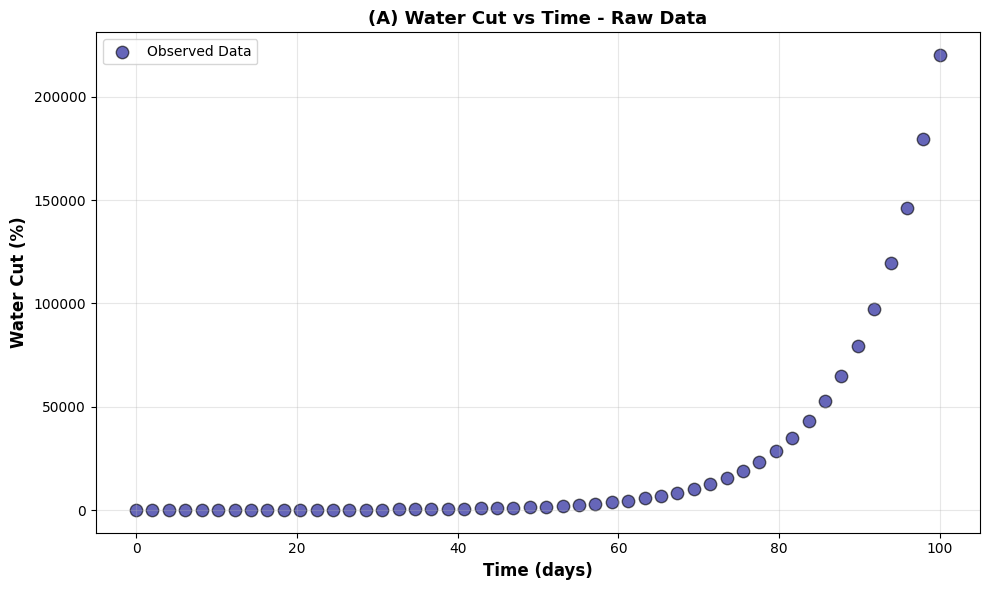

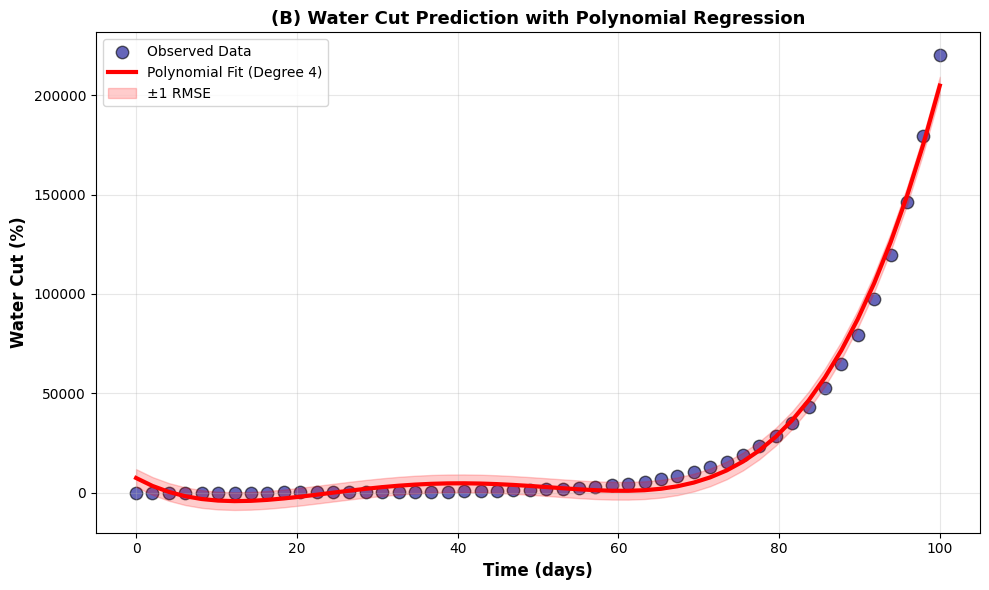

POLYNOMIAL REGRESSION RESULTS:
Polynomial Degree: 4
R² Score: 0.9915 (perfect fit = 1.0)
RMSE: 4452.7609%

Model Equation: Water Cut = f(time)
where f is a degree-4 polynomial


In [10]:
"""
Water Cut Prediction with Polynomial Regression
=================================================
Models increasing water production over time using polynomial regression.

Polynomial regression: Fits a curve rather than a line
y = a₀ + a₁×t + a₂×t² + a₃×t³ + ... + aₙ×tⁿ
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Generate synthetic water cut data
# Water cut typically increases exponentially with time
time = np.linspace(0, 100, 50)
water_cut = 10 * np.exp(0.1 * time) + 5 * np.random.rand(50)

# Plot 1: Raw data
plt.figure(figsize=(10, 6))
plt.scatter(time, water_cut, s=80, alpha=0.6, label='Observed Data', color='darkblue', edgecolors='black')
plt.xlabel("Time (days)", fontsize=12, fontweight='bold')
plt.ylabel("Water Cut (%)", fontsize=12, fontweight='bold')
plt.title("(A) Water Cut vs Time - Raw Data", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Fit polynomial regression model
degree = 4
pipeline = make_pipeline(PolynomialFeatures(degree), LinearRegression())
pipeline.fit(time.reshape(-1, 1), water_cut)
predicted_water_cut = pipeline.predict(time.reshape(-1, 1))

# Calculate metrics
r2 = r2_score(water_cut, predicted_water_cut)
rmse = np.sqrt(mean_squared_error(water_cut, predicted_water_cut))

# Plot 2: Fitted model
plt.figure(figsize=(10, 6))
plt.scatter(time, water_cut, s=80, alpha=0.6, label='Observed Data', color='darkblue', edgecolors='black')
plt.plot(time, predicted_water_cut, color='red', linewidth=3, label=f'Polynomial Fit (Degree {degree})')
plt.fill_between(time, predicted_water_cut - rmse, predicted_water_cut + rmse, 
                 color='red', alpha=0.2, label='±1 RMSE')
plt.xlabel("Time (days)", fontsize=12, fontweight='bold')
plt.ylabel("Water Cut (%)", fontsize=12, fontweight='bold')
plt.title("(B) Water Cut Prediction with Polynomial Regression", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("POLYNOMIAL REGRESSION RESULTS:")
print("=" * 60)
print(f"Polynomial Degree: {degree}")
print(f"R² Score: {r2:.4f} (perfect fit = 1.0)")
print(f"RMSE: {rmse:.4f}%")
print(f"\nModel Equation: Water Cut = f(time)")
print(f"where f is a degree-{degree} polynomial")
print("=" * 60)